In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [71]:
df=pd.read_csv("../dataset/Algerian_forest_fires_cleaned_dataset.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [72]:
df.drop(columns=["day","month","year"],inplace=True)

In [73]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [74]:
df["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [75]:
df["Classes"]=np.where(df["Classes"].str.contains("not fire"),0,1)

In [76]:
df["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [77]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [78]:
## Independent and Dependent Features
X=df.drop("FWI",axis=1)
y=df["FWI"]

In [79]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [80]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [81]:
## Checking Collinearity
corr=X_train.corr()

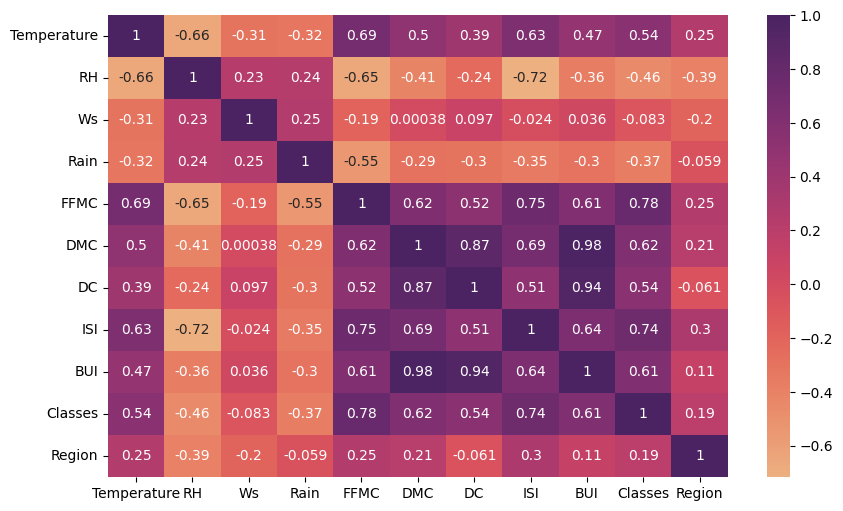

In [82]:
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap="flare")
plt.show()

In [83]:
def correlation(dataset,threshold):
    corrcol=set()
    corr=dataset.corr()
    for i in range(len(dataset.columns)):
        for j in range(i):
            if(abs(corr.iloc[i,j])>threshold):
                corrcol.add(dataset.columns[i])
    return corrcol

In [84]:
correlation(X_train,0.85)
# With Domain Knowledge I can drop as per the threshold and feature importance (as per domain)

{'BUI', 'DC'}

In [85]:
# drop features corr more than 0.85
X_train.drop(columns=["BUI","DC"],inplace=True)
X_test.drop(columns=["BUI","DC"],inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

**Feature Scaling or Standardization**

In [86]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [87]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Text(0.5, 1.0, 'X_train after Scaling')

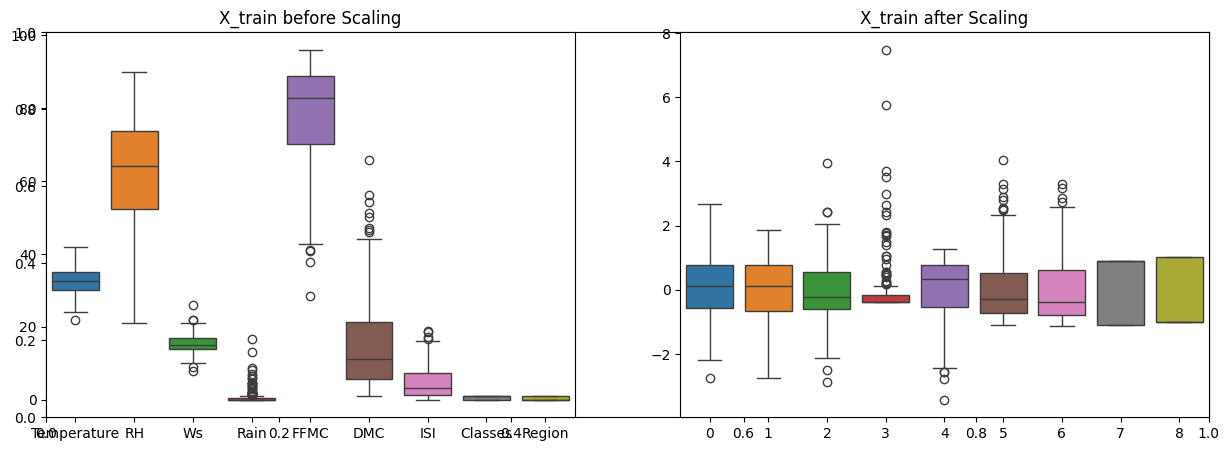

In [88]:
# Box Plot to understand the effect
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("X_train before Scaling")
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("X_train after Scaling")

# The range was completely different before, after scaling the range is standardized

mean_absolute_error(y_test,y_pred) = 0.5468236465249978
r2_score(y_test,y_pred) = 0.9847657384266951


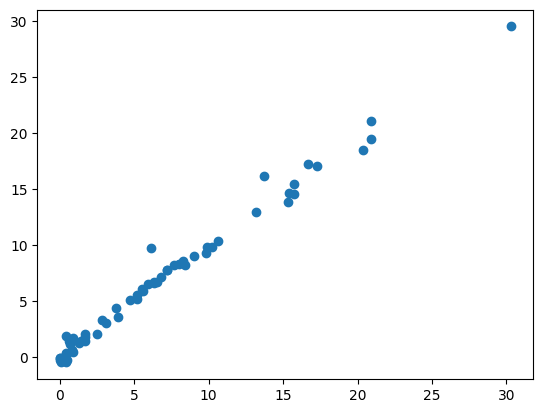

In [89]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg=LinearRegression(n_jobs=-1)
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{r2_score(y_test,y_pred) = }")
plt.scatter(y_test,y_pred)

mean_absolute_error(y_test,y_pred) = 1.1331759949144087
r2_score(y_test,y_pred) = 0.9492020263112388


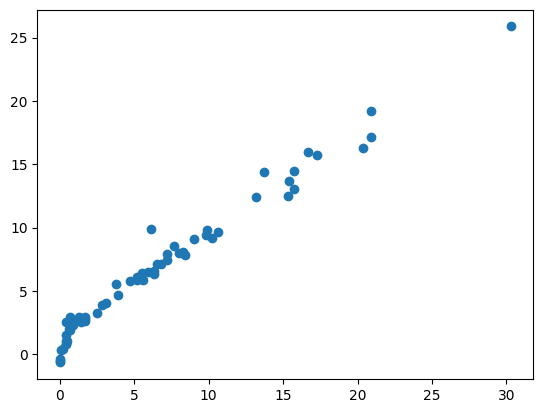

In [90]:
# Lasso Regression (used for feature selection, eliminates the less important feature)
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
lasso=Lasso() # Here lambda(i.e alpha) = 1
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{r2_score(y_test,y_pred) = }")
plt.scatter(y_test,y_pred)

mean_absolute_error(y_test,y_pred) = 0.5642305340105715
r2_score(y_test,y_pred) = 0.9842993364555512


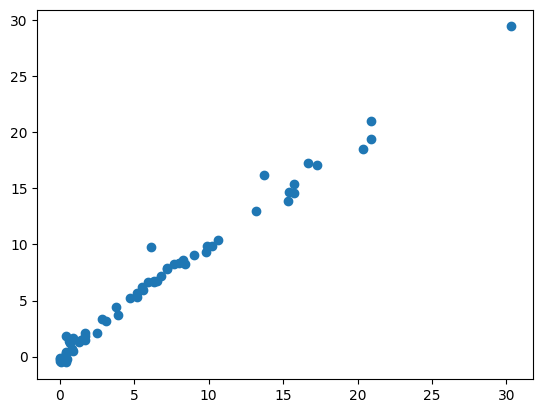

In [91]:
# Ridge Regression (used for handling overfitting)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
ridge=Ridge() # Here lambda(i.e alpha) = 1
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{r2_score(y_test,y_pred) = }")
plt.scatter(y_test,y_pred)

mean_absolute_error(y_test,y_pred) = 0.6358894638564663
r2_score(y_test,y_pred) = 0.9814406737205228


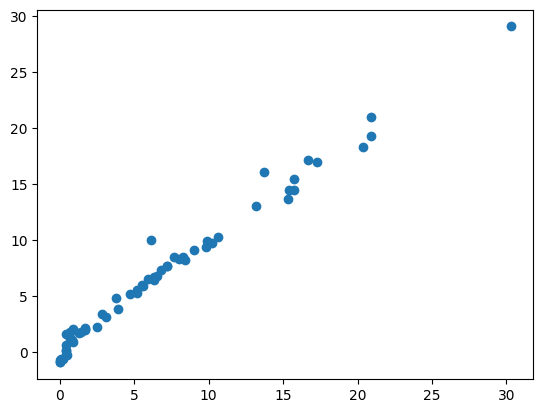

In [92]:
## Cross Validation ( LASSO )
# LassoCV
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error,r2_score
lassocv=LassoCV(cv=5) # Here using crossvalidation it will find the optimal alpha
lassocv.fit(X_train_scaled,y_train)
y_pred=lassocv.predict(X_test_scaled)
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{r2_score(y_test,y_pred) = }")
plt.scatter(y_test,y_pred)
# print(lassocv.alpha_,lassocv.alphas_) # with alpha = 0.06582808719529475 we are getting the best accuracy
# print(lassocv.get_params())

mean_absolute_error(y_test,y_pred) = 0.5642305340105715
r2_score(y_test,y_pred) = 0.9842993364555512
1.0
{'alpha_per_target': False, 'alphas': (0.1, 1.0, 10.0), 'cv': 5, 'fit_intercept': True, 'gcv_mode': None, 'scoring': None, 'store_cv_results': False}


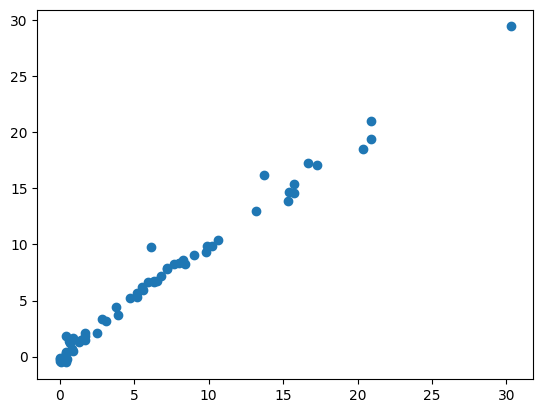

In [93]:
## Cross Validation ( RIDGE )
# RidgeCV
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,r2_score
ridgecv=RidgeCV(cv=5) # Here using crossvalidation it will find the optimal alpha
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{r2_score(y_test,y_pred) = }")
plt.scatter(y_test,y_pred)
print(ridgecv.alpha_) # with alpha = 1 we are getting the best accuracy
print(ridgecv.get_params())

mean_absolute_error(y_test,y_pred) = 1.8822353634895999
r2_score(y_test,y_pred) = 0.8753460589519703


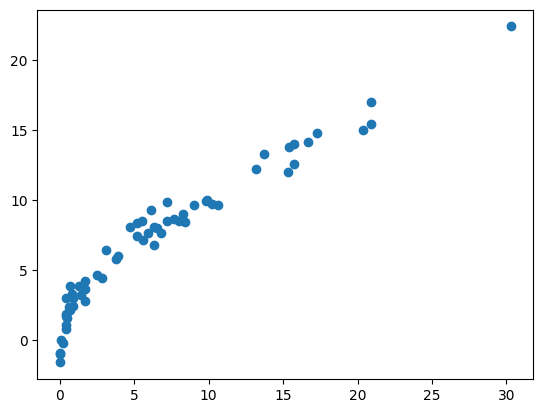

In [94]:
# Elastic Regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score
elastic=ElasticNet() # Here we can assign l1 ratio for alpha ratio assinged to l1 and l2 regression
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{r2_score(y_test,y_pred) = }")
plt.scatter(y_test,y_pred)

mean_absolute_error(y_test,y_pred) = 0.6575946731430901
r2_score(y_test,y_pred) = 0.9814217587854941
0.04311146156383891 [14.11706004 13.16561744 12.27829889 11.45078264 10.67903821  9.95930678
  9.28808283  8.66209714  8.07830078  7.53385034  7.02609405  6.55255882
  6.11093829  5.6990815   5.31498248  4.95677045  4.62270071  4.31114616
  4.02058933  3.74961507  3.49690356  3.26122397  3.04142839  2.83644629
  2.64527931  2.46699633  2.30072904  2.1456676   2.00105679  1.86619226
  1.74041714  1.62311885  1.51372607  1.411706    1.31656174  1.22782989
  1.14507826  1.06790382  0.99593068  0.92880828  0.86620971  0.80783008
  0.75338503  0.7026094   0.65525588  0.61109383  0.56990815  0.53149825
  0.49567705  0.46227007  0.43111462  0.40205893  0.37496151  0.34969036
  0.3261224   0.30414284  0.28364463  0.26452793  0.24669963  0.2300729
  0.21456676  0.20010568  0.18661923  0.17404171  0.16231189  0.15137261
  0.1411706   0.13165617  0.12278299  0.11450783  0.10679038  0.09959307
  0.

{'alphas': 'warn',
 'copy_X': True,
 'cv': None,
 'eps': 0.001,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'n_alphas': 'deprecated',
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': 0}

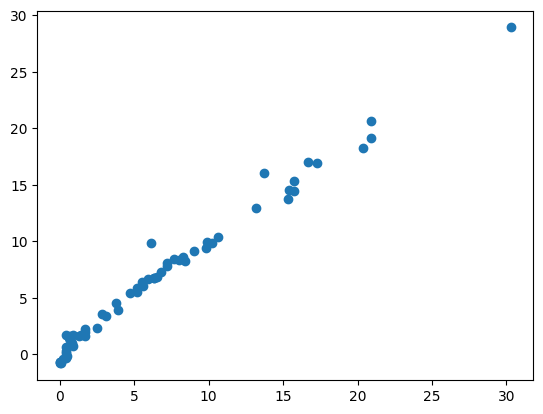

In [95]:
## Cross Validation ( ElasticNet )
# Elastic Regression
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error,r2_score
elasticcv=ElasticNetCV() # Here we can assign l1 ratio for alpha ratio assinged to l1 and l2 regression
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
print(f"{mean_absolute_error(y_test,y_pred) = }")
print(f"{r2_score(y_test,y_pred) = }")
plt.scatter(y_test,y_pred)

print(elasticcv.alpha_,elasticcv.alphas_) # at alpha 0.0431 we are getting the best accuracy i.e 98.14% (note alpha is divided equally b/w both l1 and l2 
# since l1_ratio  is 0.5)
elasticcv.get_params()

In [96]:
## Saving the Best Model -- We can see Ridge Regression is having best accuracy
## We will pickle the machine learning model and preprocessing model standardscaler

In [97]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [98]:
ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [99]:
import pickle
pickle.dump(scaler,open("../models/scaler.pkl","wb"))
pickle.dump(ridge,open("../models/ridge.pkl","wb"))

In [100]:
## To do prediction we can load the scaler.pkl, model.pkl and then we can apply
## End to End project -- Focus on implemented from this pickle file. we take input/we take output then we can see how we can deploy this in AWS
import pickle
scaler=pickle.load(open("../models/scaler.pkl","rb"))
scaler.transform(np.array([29,57,18,0.0,65.67,3.4,1.3,1,1]).reshape(1,-1))

array([[-0.84284248, -0.35227576,  0.9200267 , -0.38406017, -0.83555183,
        -0.89858211, -0.81483447,  0.90553851,  1.01105006]])